# Refactor histogram, binning of MNase-seq data
February 13, 2024

Upon realization that the MOSEK solver in cvxpy allows for fast optimization for higher resolutions. It has become clear that deconvolving the chromatin at higher resolutions becomes possible.

However, in order to take advantage of these higher resolutions, the data will need to be blurred prior to binning. Currently there is not a way to do that easily. So, the task here is to create an exact histogram/img of the chromatin data, blur appropriate, then bin/downscale to the desired resolution for deconvolution.

### Tasks
1. Create an exact histogram of the MNase-seq data
2. Blur the histogram appropriately
3. Identify the +1 nucleosome location and center our histogram around this location
    - Subset the histogram and define the genomic span for this updated region.
4. Normalize the data
5. Bin/downscale to the appropriate resolution

### Notes
- Where do we normalize the data?
    - Before or after blurring?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

gene_name = 'CLB2'
config1 = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_gene(gene_name, 1)

Loading MNase reads for CLB2...Done.


In [275]:
chromatin_model.create_deconvolution_bins()

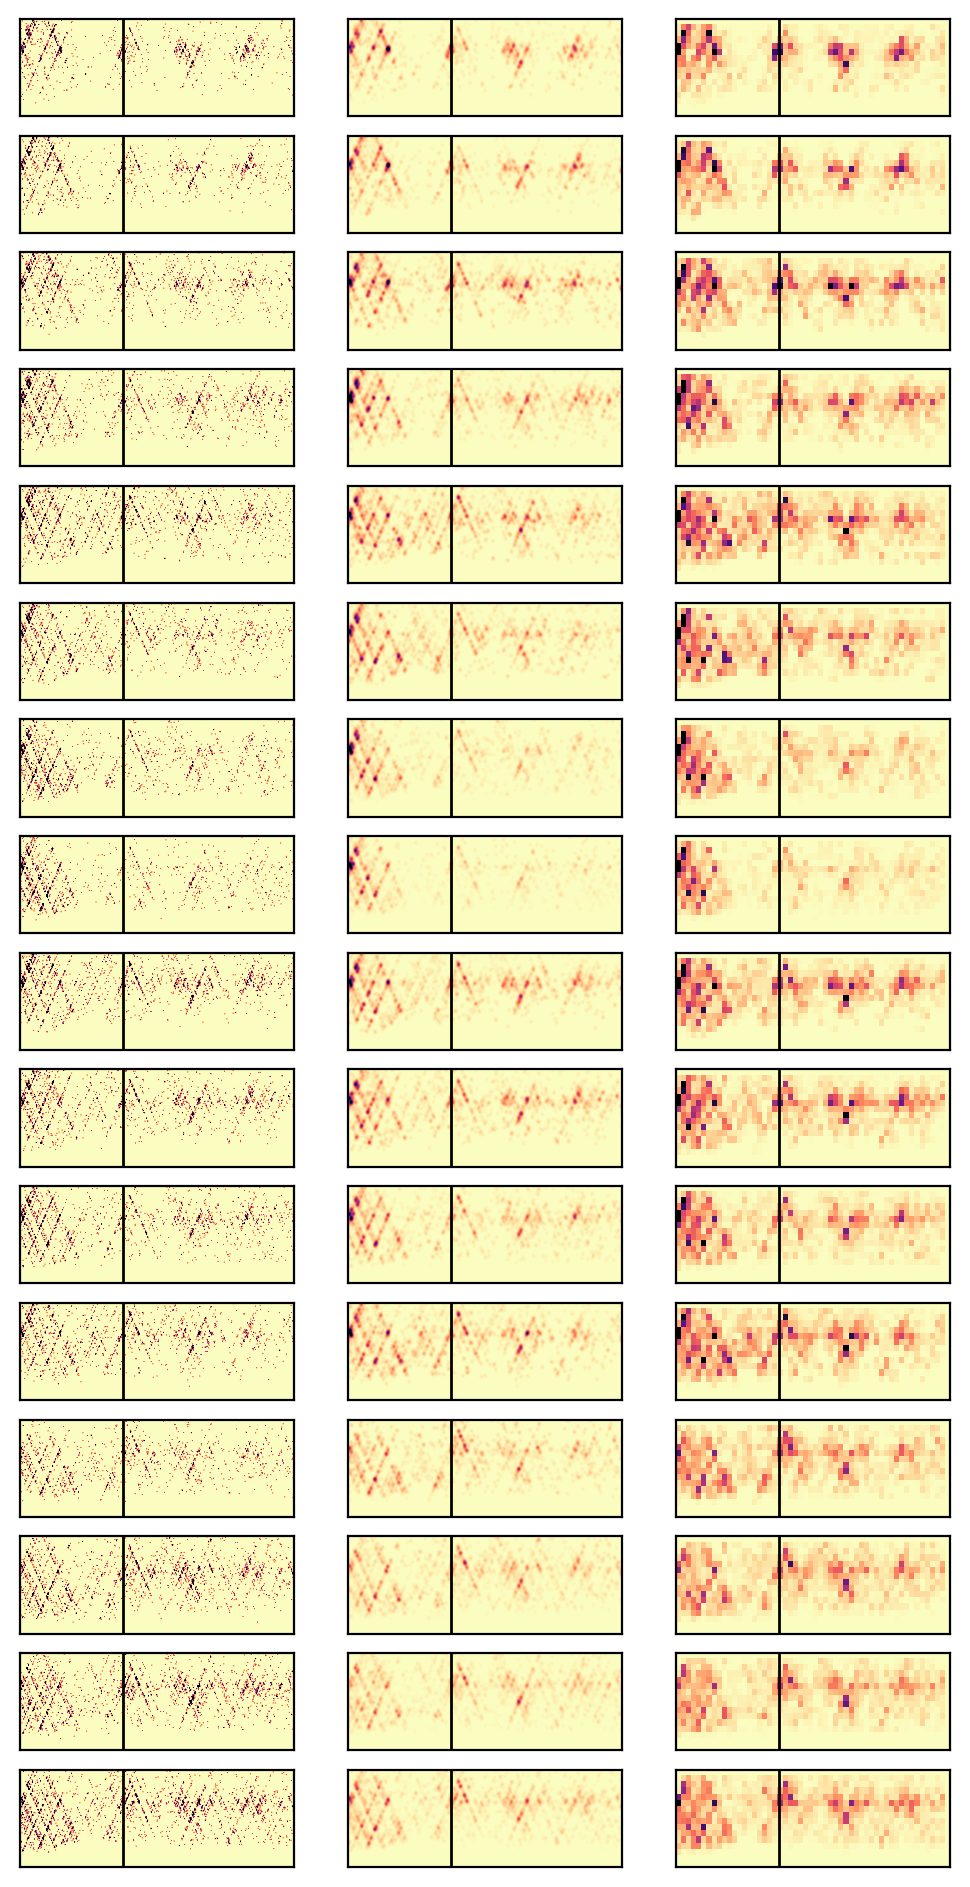

In [276]:
chromatin_model.plot_bin_comparison()

In [273]:
chromatin_model.G.shape, chromatin_model.all_hists.shape

((16, 1920), (16, 24, 80))

In [274]:
from src.deconvolve_chromatin import deconvolve_chromatin_H
import cvxpy

chromatin_model.deconvolve(solver=cvxpy.MOSEK, verbose=True)

                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Feb 13 11:36:56 AM: Your problem has 435840 variables, 1 constraints, and 0 parameters.
(CVXPY) Feb 13 11:36:56 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 13 11:36:56 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 13 11:36:56 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 13 11:36:56 AM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 13 11:36:56 AM: Compiling problem (target solver=MOSEK).

Traceback (most recent call last):
  File "/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/09/f2kb1zq9485dc8jvk0sbkbcr0000gn/T/ipykernel_82717/3578081826.py", line 4, in <module>
    chromatin_model.deconvolve(solver=cvxpy.MOSEK, verbose=True)
  File "/Users/trung/Research/deconvolution-python/cc_src/chromatin_model.py", line 1023, in deconvolve
    self.f, self.rn, self.sn = deconvolve_chromatin(self.deconv_model, self.G, solver=solver,
  File "/Users/trung/Research/deconvolution-python/src/deconvolve_chromatin.py", line 11, in deconvolve_chromatin
    return deconvolve_chromatin_H(model, model.H, g, solver=solver, verbose=verbose, allow_negative=allow_negative)
  File "/Users/trung/Research/deconvolution-python/src/deconvolve_chromatin.py", line 107, in deconvolve_chromatin_H
    matmul_res = np.matmul(H, f) / g - 1


In [ ]:
chromatin_model.f.shape

In [ ]:
chromatin_model.all_hists.shape

In [ ]:
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped(vmax=25)
